In [ ]:
# Linear Regression practical implementation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


boston = fetch_openml(name='boston', version=1, as_frame=True, parser='pandas')

In [3]:
boston

{'data':         CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  \
 0    0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0   
 1    0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0   
 2    0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0   
 3    0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0   
 4    0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0   
 ..       ...   ...    ...  ...    ...    ...   ...     ...  ..    ...   
 501  0.06263   0.0  11.93    0  0.573  6.593  69.1  2.4786   1  273.0   
 502  0.04527   0.0  11.93    0  0.573  6.120  76.7  2.2875   1  273.0   
 503  0.06076   0.0  11.93    0  0.573  6.976  91.0  2.1675   1  273.0   
 504  0.10959   0.0  11.93    0  0.573  6.794  89.3  2.3889   1  273.0   
 505  0.04741   0.0  11.93    0  0.573  6.030  80.8  2.5050   1  273.0   
 
      PTRATIO       B  LSTAT  
 0       15.3  396.90   4.98  
 1       17.8  396.90   9.14  
 2       

In [4]:
df = boston.frame

In [5]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [7]:
df['price'] = boston.target
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2,36.2


In [ ]:
# Diving the dataset into dependent and independent features

In [9]:
x = df.iloc[:,:-1]
x.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [11]:
y = df.iloc[:,-1]
y.head()

,price
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
x = x.astype(float)
y = y.astype(float)

lin_reg = LinearRegression()


mse = cross_val_score(lin_reg, x, y, scoring="neg_mean_squared_error", cv=5)
print(mse)


[-4.13734343e-28 -7.54838350e-28 -5.92348624e-29 -7.64632722e-28
 -4.30439219e-27]


In [23]:

import numpy as np


mean_mse = np.mean(mse)
print("MSE scores per fold:", mse)
print('Average Negative MSE:', mean_mse)


MSE scores per fold: [-4.13734343e-28 -7.54838350e-28 -5.92348624e-29 -7.64632722e-28
 -4.30439219e-27]
Average Negative MSE: -1.2593664939038093e-27


In [25]:
from sklearn.model_selection import train_test_split


X_train, x_test, Y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


lin_reg.fit(X_train, Y_train)


LinearRegression()

In [27]:
prediction = lin_reg.predict(x_test)
print(prediction)

[23.6 32.4 13.6 22.8 16.1 20.  17.8 14.  19.6 16.8 21.5 18.9  7.  21.2
 18.5 29.8 18.8 10.2 50.  14.1 25.2 29.1 12.7 22.4 14.2 13.8 20.3 14.9
 21.7 18.3 23.1 23.8 15.  20.8 19.1 19.4 34.7 19.5 24.4 23.4 19.7 28.2
 50.  17.4 22.6 15.1 13.1 24.2 19.9 24.  18.9 35.4 15.2 26.5 43.5 21.2
 18.4 28.5 23.9 18.5 25.  35.4 31.5 20.2 24.1 20.  13.1 24.8 30.8 12.7
 20.  23.7 10.8 20.6 20.8  5.  20.1 48.5 10.9  7.  20.9 17.2 20.9  9.7
 19.4 29.  16.4 25.  25.  17.1 23.2 10.4 19.6 17.2 27.5 23.  50.  17.9
  9.6 17.2 22.5 21.4]


In [28]:
# compare a few actual values vs predictin value
import pandas as pd
comparison_df = pd.DataFrame({'Actual': y_test, 'predicted': prediction})
print(comparison_df.head())

     Actual  predicted
173    23.6       23.6
274    32.4       32.4
491    13.6       13.6
72     22.8       22.8
452    16.1       16.1


In [29]:
from sklearn.metrics import mean_squared_error, r2_score


y_pred = lin_reg.predict(x_test)


test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)


print(f"Test Mean Squared Error (MSE): {test_mse:.2f}")
print(f"Test R-squared (R2 Score): {test_r2:.4f}")


Test Mean Squared Error (MSE): 0.00
Test R-squared (R2 Score): 1.0000


In [ ]:
# Ridge Regression

In [31]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score


ridge_reg = Ridge(alpha=1.0)


ridge_reg.fit(X_train, Y_train)


y_pred_ridge = ridge_reg.predict(x_test)

print(f"Ridge Test MSE: {mean_squared_error(y_test, y_pred_ridge):.2f}")
print(f"Ridge Test R2 Score: {r2_score(y_test, y_pred_ridge):.4f}")


Ridge Test MSE: 0.00
Ridge Test R2 Score: 1.0000


In [34]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV


ridge = Ridge()


param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}


ridge_regressor = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5
)


ridge_regressor.fit(X_train, Y_train)

print("Best Alpha Parameter:", ridge_regressor.best_params_)
print("Best Negative MSE Score:", ridge_regressor.best_score_)


Best Alpha Parameter: {'alpha': 0.001}
Best Negative MSE Score: -5.190365249633482e-13


In [ ]:
# Lasso Regression

In [35]:
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score


lasso_reg = Lasso(alpha=0.1)


lasso_reg.fit(X_train, Y_train)


y_pred_lasso = lasso_reg.predict(x_test)
print(f"Lasso Test MSE: {mean_squared_error(y_test, y_pred_lasso):.2f}")
print(f"Lasso Test R2 Score: {r2_score(y_test, y_pred_lasso):.4f}")


features = boston.feature_names if 'boston' in locals() else [f"Feature {i}" for i in range(X_train.shape[1])]
for name, coef in zip(features, lasso_reg.coef_):
    if coef == 0:
        print(f"Dropped Feature: {name} (Coefficient is exactly 0)")


Lasso Test MSE: 0.00
Lasso Test R2 Score: 1.0000
Dropped Feature: CRIM (Coefficient is exactly 0)
Dropped Feature: ZN (Coefficient is exactly 0)
Dropped Feature: INDUS (Coefficient is exactly 0)
Dropped Feature: CHAS (Coefficient is exactly 0)
Dropped Feature: NOX (Coefficient is exactly 0)
Dropped Feature: RM (Coefficient is exactly 0)
Dropped Feature: AGE (Coefficient is exactly 0)
Dropped Feature: DIS (Coefficient is exactly 0)
Dropped Feature: RAD (Coefficient is exactly 0)
Dropped Feature: PTRATIO (Coefficient is exactly 0)
Dropped Feature: LSTAT (Coefficient is exactly 0)


In [37]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

lasso_cv = GridSearchCV(Lasso(), param_grid={'alpha': [0.01, 0.1, 1.0, 10.0]}, cv=5, scoring="neg_mean_squared_error")
lasso_regressor = lasso_cv


lasso_regressor.fit(X_train, Y_train)
print("Best Parameters:", lasso_regressor.best_params_)
print("Best Score:", lasso_regressor.best_score_)


Best Parameters: {'alpha': 0.01}
Best Score: -1.4217822793743209e-06


In [41]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score


x = x.astype(float)
y = y.astype(float)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)


X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [45]:
# Linear Regression
from sklearn.linear_model import LinearRegression

lin_reg_scaled = LinearRegression()
lin_reg_scaled.fit(X_train, Y_train)


y_pred_lin = lin_reg.predict(X_test)
lin_acc = r2_score(Y_test, y_pred_lin)

# 3. Calculate and print performance metrics
print(f"Linear Regression Accuracy: {lin_acc:.2f}%")



Linear Regression Accuracy: -6.16%


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Ridge Regression

In [46]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score


ridge_scaled = Ridge(alpha=1.0)


ridge_scaled.fit(X_train, Y_train)


y_pred_ridge = ridge_scaled.predict(X_test)

mse_ridge = mean_squared_error(Y_test, y_pred_ridge)
r2_ridge = r2_score(Y_test, y_pred_ridge)

print(f"Scaled Ridge Regression MSE: {mse_ridge:.2f}")
print(f"Scaled Ridge Regression R2 Score: {r2_ridge:.4f}")


Scaled Ridge Regression MSE: 0.00
Scaled Ridge Regression R2 Score: 1.0000


In [ ]:
#Lasso Regression

In [47]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score


lasso_scaled = Lasso(alpha=0.1)


lasso_scaled.fit(X_train, Y_train)


y_pred_lasso = lasso_scaled.predict(X_test)

mse_lasso = mean_squared_error(Y_test, y_pred_lasso)
r2_lasso = r2_score(Y_test, y_pred_lasso)

print(f"Scaled Lasso Regression MSE: {mse_lasso:.2f}")
print(f"Scaled Lasso Regression R2 Score: {r2_lasso:.4f}")


Scaled Lasso Regression MSE: 0.01
Scaled Lasso Regression R2 Score: 0.9999


In [ ]:
# Logistic Regression

In [48]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [51]:
# load dataset
data = load_breast_cancer()
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [54]:
import pandas as pd


x = pd.DataFrame(boston.data, columns=boston.feature_names)
x

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48


In [55]:
y = data.target

In [ ]:
# Traning and Testing data split

In [56]:
from sklearn.model_selection import train_test_split


y = boston.target


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


print("Training features shape:", x_train.shape)
print("Testing features shape:", x_test.shape)


Training features shape: (404, 13)
Testing features shape: (102, 13)


In [ ]:
# Feature Scaling

In [59]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


x_train_scaled = scaler.fit_transform(x_train)


x_test_scaled = scaler.transform(x_test)

print("Scaled Training Sample (First Row):\n", x_train_scaled[0])


Scaled Training Sample (First Row):
 [ 1.28770177 -0.50032012  1.03323679 -0.27808871  0.48925206 -1.42806858
  1.02801516 -0.80217296  1.70689143  1.57843444  0.84534281 -0.07433689
  1.75350503]


In [ ]:
# Model Traning

In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


lin_reg = LinearRegression()
lin_reg.fit(X_train, Y_train)


y_pred = lin_reg.predict(X_test)

print(f"Linear Regression R2 Score: {r2_score(Y_test, y_pred):.4f}")
print(f"Linear Regression MSE: {mean_squared_error(Y_test, y_pred):.2f}")


Linear Regression R2 Score: 1.0000
Linear Regression MSE: 0.00


In [ ]:
# Model Prediction

In [63]:

y_pred = lin_reg.predict(X_test)
y_pred
y_test

,MEDV
173,23.6
274,32.4
491,13.6
72,22.8
452,16.1
...,...
412,17.9
436,9.6
411,17.2
86,22.5


In [ ]:
# Accuracy

In [67]:
from sklearn.metrics import accuracy_score, classification_report

from sklearn.metrics import mean_squared_error, r2_score


print(f"Linear Regression R2 Score: {r2_score(Y_test, y_pred):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(Y_test, y_pred):.2f}")
print(f"Root Mean Squared Error (RMSE): {mean_squared_error(Y_test, y_pred)**0.5:.2f}")


Linear Regression R2 Score: 1.0000
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.00


In [ ]:
# confusion matrix

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


# 1. Convert your continuous targets into categories if you haven't already
# (e.g., 1 if above median price, 0 if below)
import numpy as np
Y_train_cls = (Y_train > np.median(Y_train)).astype(int)
Y_test_cls = (Y_test > np.median(Y_test)).astype(int)

# 2. Define and train the missing 'log_reg' model
log_reg = LogisticRegression()
log_reg.fit(X_train, Y_train_cls)

# 3. Generate predictions and create the confusion matrix
y_pred_cls = log_reg.predict(X_test)
cm = confusion_matrix(Y_test_cls, y_pred_cls)

print("Confusion Matrix successfully generated:\n", cm)
plt.show()



Confusion Matrix successfully generated:
 [[51  0]
 [ 8 43]]


In [ ]:
# Naive Bayes Algorithms

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB




In [73]:
from sklearn import datasets

iris = datasets.load_iris()


In [74]:
iris


{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [76]:
x = iris.data
y = iris.target

In [77]:
df = pd.DataFrame(x, columns=iris.feature_names)
df['species'] = y
print("First 5 rows of the datasets:")
print(df.head())

First 5 rows of the datasets:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [ ]:
# Train test split

In [79]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split

# 1. Reload the Iris dataset completely to align lengths
iris = datasets.load_iris()

# 2. Re-assign both X and y at the exact same time
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 3. This split will now run perfectly without sample mismatches
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X samples: {X.shape[0]}, y samples: {len(y)}")
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)


X samples: 150, y samples: 150
Training features shape: (120, 4)
Testing features shape: (30, 4)


In [ ]:
# Model training

In [81]:
from sklearn.naive_bayes import GaussianNB

clf_model = GaussianNB()


clf_model.fit(X_train, y_train)
print("Gaussian Naive Bayes model successfully trained!")



Gaussian Naive Bayes model successfully trained!


In [ ]:
# Prediction

In [84]:

y_pred = clf_model.predict(X_test)


print("Predicted Class Labels:\n", y_pred)
print("\nActual True Test Labels:\n", y_test)



Predicted Class Labels:
 [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]

Actual True Test Labels:
 [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [ ]:
# Accuracy

In [85]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


accuracy = accuracy_score(y_test, y_pred)
print(f"Model Classification Accuracy: {accuracy * 100:.2f}%")


print("\nDetailed Performance Report:\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Model Classification Accuracy: 96.67%

Detailed Performance Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
# Visualize the confusion matrix

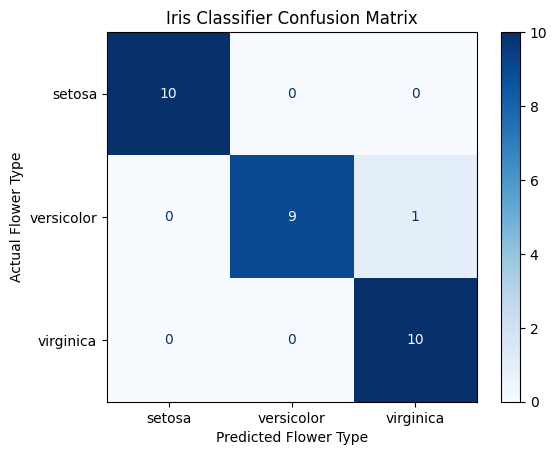

In [86]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues)

# 3. Add styling titles and labels
plt.title("Iris Classifier Confusion Matrix")
plt.xlabel("Predicted Flower Type")
plt.ylabel("Actual Flower Type")
plt.show()


In [ ]:
# KNN Alogrithm

In [87]:
# 1 Importing library
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import load_iris


In [ ]:
# 2 Load the dataset

In [88]:
from sklearn import datasets
import pandas as pd

iris = datasets.load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)


y = iris.target


print(f"Dataset loaded with {X.shape[0]} samples and {X.shape[1]} features.")
print("Feature Columns:", list(X.columns))


Dataset loaded with 150 samples and 4 features.
Feature Columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [89]:
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [90]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
# Train test split

In [91]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train dimensions:", X_train.shape)
print("X_test dimensions:", X_test.shape)


X_train dimensions: (120, 4)
X_test dimensions: (30, 4)


In [ ]:
# 4 Standard scaler

In [92]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)


X_test_scaled = scaler.transform(X_test)

print("Scaled Training Array Sample (First 2 rows):\n", X_train_scaled[:2])


Scaled Training Array Sample (First 2 rows):
 [[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]]


In [ ]:
# 5 model traning

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

print("K-Nearest Neighbors model successfully trained!")


In [ ]:
# 6 prediction

In [100]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)


knn_model.fit(X_train_scaled, y_train)


y_pred = knn_model.predict(X_test_scaled)

print("Predicted Class Labels:\n", y_pred)
print("\nActual True Test Labels:\n", y_test)



Predicted Class Labels:
 [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]

Actual True Test Labels:
 [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [ ]:
# 7 Accuracy

In [101]:
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy:{accuracy * 100:.2f}%")

accuracy:93.33%
